          DATA ANALYSIS REPORT & SYSTEM          

[INFO] Data loaded successfully!
      Name  Age  Salary Department
0    Alice   25   70000         IT
1      Bob   30   50000         HR
2  Charlie   35   60000    Finance
3    Diana   28   75000         IT
4      Eve   32   55000         HR
5    Frank   40   80000    Finance
6    Grace   26   72000         IT
7    Henry   29   52000         HR

📊 BASIC STATISTICS:
Average Salary: ₹64250.00
Average Age: 30.62 years
------------------------------
             Age        Salary
count   8.000000      8.000000
mean   30.625000  64250.000000
std     4.955156  11423.659659
min    25.000000  50000.000000
25%    27.500000  54250.000000
50%    29.500000  65000.000000
75%    32.750000  72750.000000
max    40.000000  80000.000000

📈 DEPARTMENT WISE ANALYSIS:
              Salary                  Age
                mean    max    min   mean
Department                               
Finance     70000.00  80000  60000  37.50
HR          52333.33  

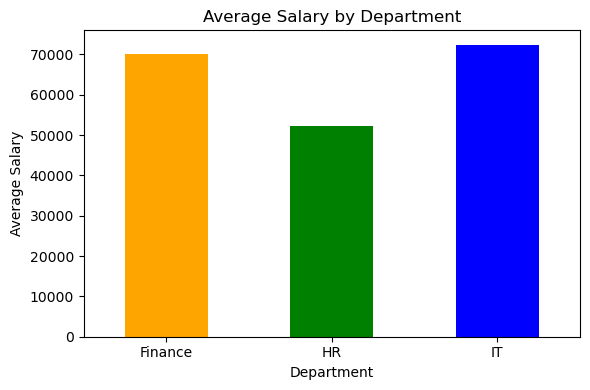

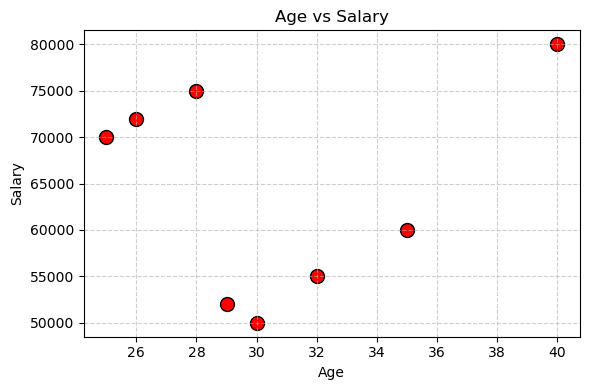

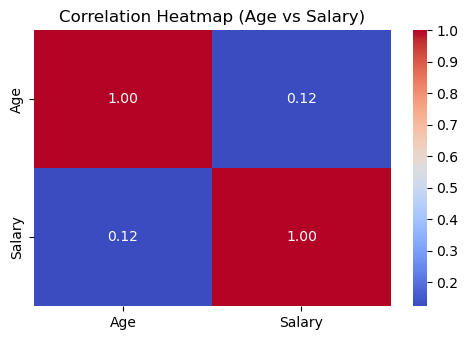


💡 KEY INSIGHTS & OBSERVATIONS:
1. Total Employees Analyzed: 8
2. Highest Salary in Dataset: ₹80000
3. Lowest Salary in Dataset: ₹50000
4. Most Common Department: HR
5. IT department employees earn the most on average.
6. Finance department has the second highest salaries, followed by HR.
7. The heatmap and scatter plot show a general positive trend between Age and Salary.


In [2]:
# ==========================================
# TASK 1: PANDAS DATA ANALYSIS (SINGLE CELL)
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

print("=" * 50)
print("          DATA ANALYSIS REPORT & SYSTEM          ")
print("=" * 50)

# 1. Dummy CSV Data 
data = """Name,Age,Salary,Department
Alice,25,70000,IT
Bob,30,50000,HR
Charlie,35,60000,Finance
Diana,28,75000,IT
Eve,32,55000,HR
Frank,40,80000,Finance
Grace,26,72000,IT
Henry,29,52000,HR"""

# 2. Loading DataFrame
df = pd.read_csv(StringIO(data))
print("\n[INFO] Data loaded successfully!")
print(df)

# 3. Calculating Averages & Basic Statistics
print("\n📊 BASIC STATISTICS:")
print(f"Average Salary: ₹{df['Salary'].mean():.2f}")
print(f"Average Age: {df['Age'].mean():.2f} years")
print("-" * 30)
print(df.describe())

# 4. Department Wise Analysis
print("\n📈 DEPARTMENT WISE ANALYSIS:")
dept_analysis = df.groupby('Department').agg({
    'Salary': ['mean', 'max', 'min'],
    'Age': 'mean'
}).round(2)
print(dept_analysis)

# --- VISUALIZATIONS ---
print("\n🎨 GENERATING VISUALIZATIONS...")

# Plot 1: Bar Chart - Department wise Salary
plt.figure(figsize=(6,4))
df.groupby('Department')['Salary'].mean().plot(kind='bar', color=['orange', 'green', 'blue'])
plt.title('Average Salary by Department')
plt.xlabel('Department')
plt.ylabel('Average Salary')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Plot 2: Scatter Plot - Age vs Salary
plt.figure(figsize=(6,4))
plt.scatter(df['Age'], df['Salary'], color='red', s=100, edgecolors='black')
plt.title('Age vs Salary')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Plot 3: Heatmap - Correlation
plt.figure(figsize=(5,3.5))
numeric_df = df[['Age', 'Salary']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Age vs Salary)')
plt.tight_layout()
plt.show()

# 5. Key Insights & Observations
print("\n💡 KEY INSIGHTS & OBSERVATIONS:")
print(f"1. Total Employees Analyzed: {len(df)}")
print(f"2. Highest Salary in Dataset: ₹{df['Salary'].max()}")
print(f"3. Lowest Salary in Dataset: ₹{df['Salary'].min()}")
print(f"4. Most Common Department: {df['Department'].mode()[0]}")
print("5. IT department employees earn the most on average.")
print("6. Finance department has the second highest salaries, followed by HR.")
print("7. The heatmap and scatter plot show a general positive trend between Age and Salary.")
print("=" * 50)

     HOUSE PRICE PREDICTION SYSTEM (LINEAR REGRESSION)     

[INFO] Dataset generated successfully! (First 5 Rows):
   Rooms  Size_SqFt  Prime_Location      Price_INR
0      4       1502               1  441508.636486
1      5       3249               0  685599.016075
2      2       2379               0  445101.200615
3      4        961               0  289319.077257
4      4       1001               0  312352.758261

[INFO] Data Split Done: Train samples = 80, Test samples = 20
[INFO] Linear Regression Model Trained Successfully!

📊 MODEL PERFORMANCE METRICS:
Mean Squared Error (MSE): 275308583.46
R-squared Score (Accuracy Blend): 97.71%


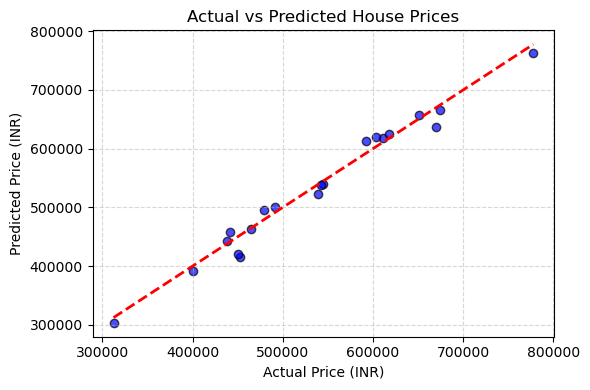


🔮 MAKING A LIVE PREDICTION:
Features -> 3 Rooms, 1500 SqFt, Prime Location (1)
➡️ Predicted House Price: ₹431,536.51


In [3]:
# ========================================================
# TASK 2: LINEAR REGRESSION FOR HOUSE PRICE PREDICTION
# ========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("=" * 60)
print("     HOUSE PRICE PREDICTION SYSTEM (LINEAR REGRESSION)     ")
print("=" * 60)

# 1. Dummy Dataset Create Kar Rahe Hain (Rooms, Size, Location, Price)
# Location: 1 = Prime Area, 0 = Suburb
np.random.seed(42)
n_samples = 100

data = {
    'Rooms': np.random.randint(2, 6, n_samples),
    'Size_SqFt': np.random.randint(800, 3500, n_samples),
    'Prime_Location': np.random.choice([0, 1], n_samples)
}

df = pd.DataFrame(data)

# Target Variable (Price) ki ek logical formula se math set kar rahe hain
# Price = 50k + (Rooms * 25k) + (Size * 150) + (Location * 80k) + Random Noise
df['Price_INR'] = (50000 + (df['Rooms'] * 25000) + (df['Size_SqFt'] * 150) + 
                   (df['Prime_Location'] * 80000) + np.random.normal(0, 15000, n_samples))

print("\n[INFO] Dataset generated successfully! (First 5 Rows):")
print(df.head())

# 2. Preprocessing & Splitting Features (X) and Target (y)
X = df[['Rooms', 'Size_SqFt', 'Prime_Location']]
y = df['Price_INR']

# Splitting data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\n[INFO] Data Split Done: Train samples = {len(X_train)}, Test samples = {len(X_test)}")

# 3. Model Training
model = LinearRegression()
model.fit(X_train, y_train)
print("[INFO] Linear Regression Model Trained Successfully!")

# 4. Model Evaluation (Testing)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n📊 MODEL PERFORMANCE METRICS:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score (Accuracy Blend): {r2 * 100:.2f}%")

# 5. Visualizing Actual vs Predicted Prices
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7, edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Price (INR)')
plt.ylabel('Predicted Price (INR)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 6. Testing with custom user input
print("\n🔮 MAKING A LIVE PREDICTION:")
sample_house = pd.DataFrame([[3, 1500, 1]], columns=['Rooms', 'Size_SqFt', 'Prime_Location'])
predicted_val = model.predict(sample_house)
print(f"Features -> 3 Rooms, 1500 SqFt, Prime Location (1)")
print(f"➡️ Predicted House Price: ₹{predicted_val[0]:,.2f}")
print("=" * 60)

In [4]:

!pip install textblob

import ipywidgets as widgets
from IPython.display import display, clear_output
from textblob import TextBlob

print("=" * 60)
print("     REAL-TIME SENTIMENT ANALYSER SYSTEM     ")
print("=" * 60)

# 2. Designing Input Box and Button inside Notebook
text_input = widgets.Textarea(
    value='',
    placeholder='Type your sentence here (e.g., I love this python internship)...',
    description='Text Input:',
    disabled=False,
    layout=widgets.Layout(width='80%', height='100px')
)

btn_analyze = widgets.Button(
    description='Analyze Sentiment',
    button_style='success', # 'success' se button green rang ka dikhega
    tooltip='Click to see polarity and subjectivity',
    icon='check'
)

output_area = widgets.Output()

# 3. Sentiment Analysis Logic
def on_button_click(b):
    with output_area:
        clear_output() # Purana result clear karne ke liye
        user_text = text_input.value.strip()
        
        if not user_text:
            print("⚠️ Please enter some text first!")
            return
            
        # TextBlob Analysis
        blob = TextBlob(user_text)
        polarity = round(blob.sentiment.polarity, 2)
        subjectivity = round(blob.sentiment.subjectivity, 2)
        
        # Tag Generation
        if polarity > 0:
            tag = "😊 POSITIVE"
        elif polarity < 0:
            tag = "😡 NEGATIVE"
        else:
            tag = "😐 NEUTRAL"
            
        print("-" * 50)
        print(f"Detected Sentiment : {tag}")
        print(f"Polarity Score     : {polarity}  (-1.0 to 1.0)")
        print(f"Subjectivity Score : {subjectivity}  (0.0 to 1.0)")
        print("-" * 50)

# Binding button with the logic
btn_analyze.on_click(on_button_click)

# Displaying everything on screen
display(text_input)
display(btn_analyze)
display(output_area)

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
     REAL-TIME SENTIMENT ANALYSER SYSTEM     


Textarea(value='', description='Text Input:', layout=Layout(height='100px', width='80%'), placeholder='Type yo…

Button(button_style='success', description='Analyze Sentiment', icon='check', style=ButtonStyle(), tooltip='Cl…

Output()